### 01. Import

In [1]:
import pandas as pd
import numpy as np

path = "../data/df_adem_enedis_iris_69.csv" 
df = pd.read_csv(path)

print("Shape:", df.shape)
df.head(5)

Shape: (358302, 40)


,conso_5_usages_ep,emission_ges_5_usages,nom_commune_ban,type_logement_source,cout_total_5_usages,etiquette_ges,methode_application_dpe,type_energie_principale_chauffage,code_region_ban,conso_refroidissement_ep,...,code_postal_ban,zone_climatique,qualite_isolation_menuiseries,date_reception_dpe,emission_ges_chauffage,codeiris,conso_totale_mwh,conso_moy_site_mwh,conso_moy_commune_mwh,nombre_de_logements
0,16721.9,547.5,ALBIGNY-SUR-SAÔNE,EXISTANT,1238.0,C,DPE APPARTEMENT INDIVIDUEL,ÉLECTRICITÉ,84.0,0.0,...,69250,H1C,INSUFFISANTE,2022-04-02,10.6,690030000,6429.986,2.725961,4.559143,2741.0
1,28697.8,6286.9,ALBIGNY-SUR-SAÔNE,EXISTANT,2174.0,F,DPE APPARTEMENT INDIVIDUEL,GAZ NATUREL,84.0,0.0,...,69250,H1C,MOYENNE,2022-06-23,25.4,690030000,6429.986,2.725961,4.559143,2741.0
2,7437.8,1435.8,NEUVILLE-SUR-SAÔNE,EXISTANT,756.7,C,DPE APPARTEMENT INDIVIDUEL,GAZ NATUREL,84.0,0.0,...,69250,H1C,BONNE,2022-06-07,955.9,691430104,7800.521,2.302478,3.265994,3366.0
3,13047.5,2659.4,NEUVILLE-SUR-SAÔNE,EXISTANT,1175.0,C,DPE APPARTEMENT INDIVIDUEL,GAZ NATUREL,84.0,0.0,...,69250,H1C,BONNE,2022-01-14,2120.9,691430104,7800.521,2.302478,3.265994,3366.0
4,5616.0,1044.3,ALBIGNY-SUR-SAÔNE,EXISTANT,642.0,C,DPE APPARTEMENT INDIVIDUEL,GAZ NATUREL,84.0,0.0,...,69250,H1C,BONNE,2022-06-14,613.8,690030000,6429.986,2.725961,4.559143,2741.0


### 02. Regrouper les classes DPE

In [14]:
def regroupe_etiquette(etiquette):
    if etiquette in ['A', 'B']:
        return 'A_B'
    elif etiquette == 'C':
        return 'C'
    elif etiquette == 'D':
        return 'D'
    elif etiquette == 'E':
        return 'E'
    elif etiquette in ['F', 'G']:
        return 'F_G'
    else:
        return None

df["etiquette_dpe_regroupee"] = df["etiquette_dpe"].apply(regroupe_etiquette)


### 03. Nettoyage des données

In [15]:
drop_cols = [
    "numero_dpe", "date_fin_validite_dpe", "date_reception_dpe",
    "coordonnee_cartographique_x_ban", "coordonnee_cartographique_y_ban",
    "_score", "etiquette_ges", "modele_dpe", "version_dpe", "nom_commune_ban",
    "etiquette_dpe"  
]
df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")

### 04. Feature Engineering

#### Variables dérivées physiques

In [16]:
df["conso_m2"] = df["conso_5_usages_ep"] / df["surface_habitable_logement"]
df["cout_m2"] = df["cout_total_5_usages"] / df["surface_habitable_logement"]

# Âge du logement
df["anciennete"] = 2025 - df["annee_construction"]

# Volume approximatif du logement
df["volume_logement"] = df["surface_habitable_logement"] * df["hauteur_sous_plafond"]

#### Variables catégorielles

In [17]:
def simplifie_zone(zone):
    if pd.isna(zone):
        return None
    if "H1" in zone:
        return "froid"
    elif "H2" in zone:
        return "tempéré"
    elif "H3" in zone:
        return "chaud"
    else:
        return "inconnu"

df["zone_clim_simplifiee"] = df["zone_climatique"].apply(simplifie_zone)

In [18]:
def regroupe_energie(energie):
    if pd.isna(energie):
        return None
    energie = energie.lower()
    if "élec" in energie or "elect" in energie:
        return "electrique"
    elif "gaz" in energie:
        return "gaz"
    elif "fioul" in energie or "fuel" in energie:
        return "fioul"
    elif "bois" in energie:
        return "bois"
    else:
        return "autre"

df["energie_regroupee"] = df["type_energie_principale_chauffage"].apply(regroupe_energie)

In [21]:
# Score moyen d’isolation
def score_isolation(row):
    mapping = {"faible": 1, "moyenne": 2, "bonne": 3}
    cols = ["qualite_isolation_murs", "qualite_isolation_menuiseries", "isolation_toiture"]
    vals = [mapping.get(str(row[c]).lower(), np.nan) for c in cols]
    vals = [v for v in vals if not np.isnan(v)]
    return np.mean(vals) if len(vals) > 0 else np.nan

df["score_isolation_moyen"] = df.apply(score_isolation, axis=1)

In [22]:
# Classe d’année de construction
def classe_annee(annee):
    if pd.isna(annee):
        return None
    elif annee < 1948:
        return "avant_1948"
    elif annee < 1975:
        return "1949_1974"
    elif annee < 1990:
        return "1975_1989"
    elif annee < 2000:
        return "1990_1999"
    elif annee < 2012:
        return "2000_2011"
    else:
        return "apres_2012"

df["classe_annee_construction"] = df["annee_construction"].apply(classe_annee)

### 05. Analyse de corrélation entre les variables numériques

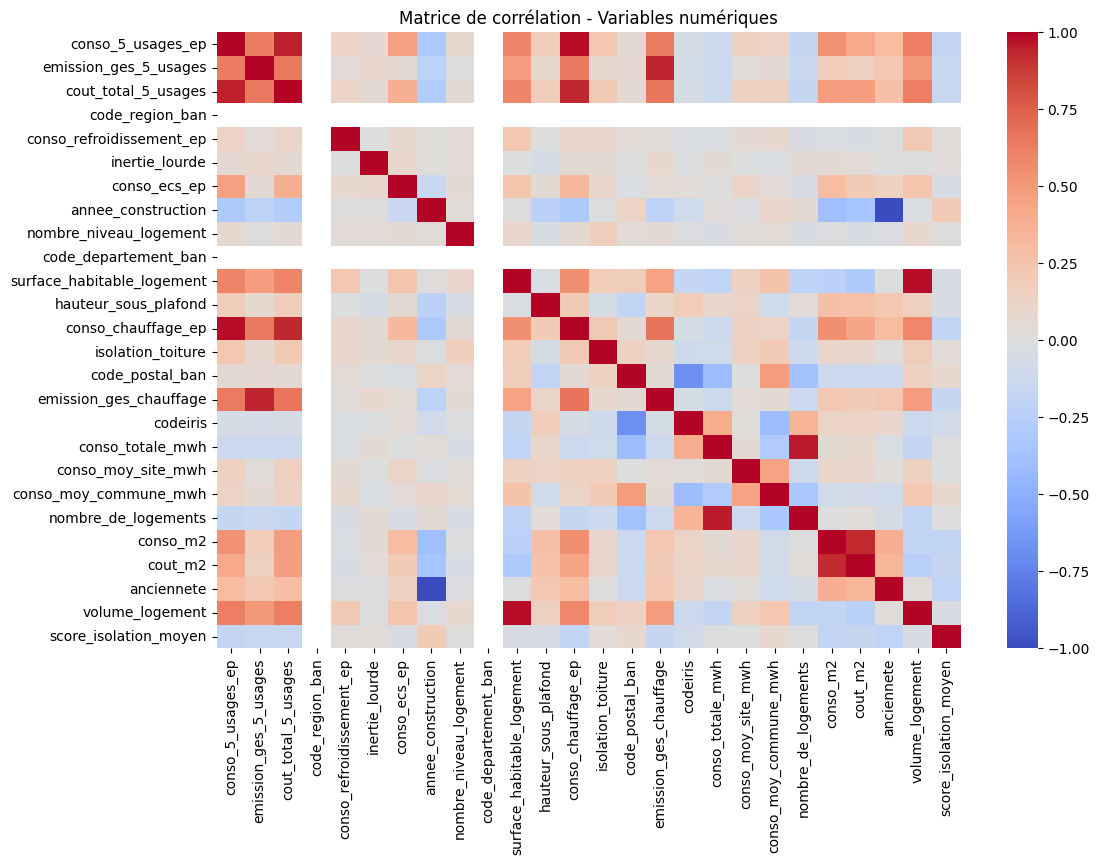

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Corrélation uniquement sur les variables numériques
corr = df.select_dtypes(include=['number']).corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Matrice de corrélation - Variables numériques")
plt.show()

In [26]:
drop_corr = [
    "emission_ges_5_usages", "cout_total_5_usages",
    "conso_totale_mwh", "conso_moy_site_mwh", "conso_moy_commune_mwh",
    "nombre_de_logements"
]
df = df.drop(columns=[c for c in drop_corr if c in df.columns], errors="ignore")

#### les variables les plus corrélées à la consommation

In [27]:
target_corr = corr["conso_5_usages_ep"].sort_values(ascending=False)
print(target_corr.head(10))

conso_5_usages_ep             1.000000
conso_chauffage_ep            0.977690
cout_total_5_usages           0.946921
emission_ges_chauffage        0.638952
emission_ges_5_usages         0.629668
volume_logement               0.623989
surface_habitable_logement    0.599584
conso_m2                      0.531304
conso_ecs_ep                  0.468313
cout_m2                       0.417032
Name: conso_5_usages_ep, dtype: float64


- la corrélation avec conso_5_usages_ep aide à comprendre les variables physiques influentes.

In [29]:
drop_corr = [
    "conso_chauffage_ep",
    "cout_total_5_usages",
    "emission_ges_5_usages",
    "emission_ges_chauffage"
]

df = df.drop(columns=[c for c in drop_corr if c in df.columns], errors="ignore")

#### la corrélation entre features et cible

In [30]:
from sklearn.preprocessing import LabelEncoder

# Encoder temporairement la cible pour calculer une corrélation
le = LabelEncoder()
df["target_encoded"] = le.fit_transform(df["etiquette_dpe_regroupee"])

corr_target = df.corr(numeric_only=True)["target_encoded"].sort_values(ascending=False)
corr_target.head(10)

target_encoded          1.000000
conso_m2                0.873467
cout_m2                 0.801156
conso_5_usages_ep       0.565656
anciennete              0.416261
conso_ecs_ep            0.292128
hauteur_sous_plafond    0.279830
isolation_toiture       0.099636
codeiris                0.095187
inertie_lourde          0.061920
Name: target_encoded, dtype: float64

In [36]:
df = df.drop(columns=["target_encoded"], errors="ignore")

In [32]:
drop_lowinfo = [
    "cout_m2",
    "conso_5_usages_ep",
    "codeiris",
    "inertie_lourde"
]
df = df.drop(columns=[c for c in drop_lowinfo if c in df.columns], errors="ignore")

In [37]:
print("Colonnes conservées pour la modélisation :")
print(len(df.columns.tolist()))
print(df.columns.tolist())

Colonnes conservées pour la modélisation :
27
['type_logement_source', 'methode_application_dpe', 'type_energie_principale_chauffage', 'code_region_ban', 'conso_refroidissement_ep', 'qualite_isolation_murs', 'type_batiment', 'conso_ecs_ep', 'annee_construction', 'nombre_niveau_logement', 'type_installation_ecs', 'code_departement_ban', 'surface_habitable_logement', 'type_installation_chauffage', 'hauteur_sous_plafond', 'isolation_toiture', 'code_postal_ban', 'zone_climatique', 'qualite_isolation_menuiseries', 'etiquette_dpe_regroupee', 'conso_m2', 'anciennete', 'volume_logement', 'zone_clim_simplifiee', 'energie_regroupee', 'score_isolation_moyen', 'classe_annee_construction']


In [43]:
df.to_csv("../data/Prepared/prepared_dpe_regroupe_final.csv", index=False)
print("Dataset final enregistré : data/prepared_dpe_regroupe_final.csv")

Dataset final enregistré : data/prepared_dpe_regroupe_final.csv
